# IMPORT MODULES AND LOAD TABLES

In [1]:
# ── CELL 1: Setup ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from google.colab import files

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.alpha': 0.35, 'font.size': 12,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
})
BLUE, RED, ORANGE, GREEN, GRAY, PURPLE = (
    '#2563EB','#DC2626','#F59E0B','#16A34A','#6B7280','#7C3AED')
print("Setup complete.")

Setup complete.


In [2]:
# ── CELL 2: Load all 13 CSVs ──────────────────────────────────

df_advance   = pd.read_csv('/content/A - How many days before departure does price spike significantly?.csv')
df_scarcity  = pd.read_csv('/content/B - Are flights more expensive with fewer seats remaining?.csv')
df_scarcity_timing = pd.read_csv('/content/B - Scarcity effect controlling for advance window.csv')
df_refundable= pd.read_csv('/content/C - Are refundable flights more expensive?.csv')
df_cabin     = pd.read_csv('/content/C - Cabin class distribution and pricing.csv')
df_refund_routes = pd.read_csv('/content/C - Do airlines hide refundable options on certain routes?.csv')
df_duration  = pd.read_csv('/content/D - After which flight duration does price increase significantly?.csv')
df_stops     = pd.read_csv('/content/D - Are flights with more stops cheaper?.csv')
df_airport   = pd.read_csv('/content/D - Are some airports more expensive than others at the same distance?.csv')
df_monopoly  = pd.read_csv('/content/D - Monopoly pricing — do routes with fewer airlines charge more?.csv')
df_seasonal  = pd.read_csv('/content/ADD - Price consistency over time.csv')
df_volatility= pd.read_csv('/content/ADD - Price volatility per airline.csv')
df_sameday   = pd.read_csv('/content/ADD - Same-day search price vs advance search.csv')

df_seasonal['SEARCH_WEEK'] = pd.to_datetime(df_seasonal['SEARCH_WEEK'])
print("All 13 files loaded successfully.")

All 13 files loaded successfully.


# CHARTS

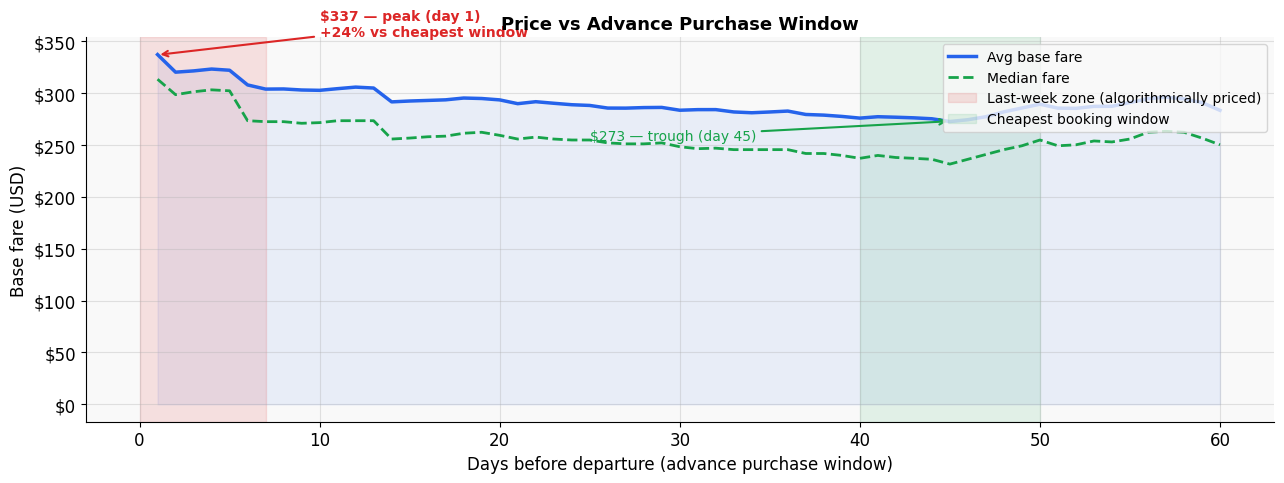

In [3]:
# ── CELL 3: Chart 1 — The U-curve (advance window) ───────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(df_advance['DAYS_ADVANCE'], df_advance['AVG_FARE'],
                alpha=0.08, color=BLUE)
ax.plot(df_advance['DAYS_ADVANCE'], df_advance['AVG_FARE'],
        color=BLUE, lw=2.5, label='Avg base fare')
ax.plot(df_advance['DAYS_ADVANCE'], df_advance['MEDIAN_FARE'],
        color=GREEN, lw=2, ls='--', label='Median fare')

ax.axvspan(0, 7,  alpha=0.12, color=RED,   label='Last-week zone (algorithmically priced)')
ax.axvspan(40, 50, alpha=0.10, color=GREEN, label='Cheapest booking window')

ax.annotate('$337 — peak (day 1)\n+24% vs cheapest window',
            xy=(1, 337), xytext=(10, 355),
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.5),
            color=RED, fontsize=10, fontweight='bold')
ax.annotate('$273 — trough (day 45)',
            xy=(45, 273), xytext=(25, 255),
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5),
            color=GREEN, fontsize=10)

ax.set_xlabel('Days before departure (advance purchase window)')
ax.set_ylabel('Base fare (USD)')
ax.set_title('Price vs Advance Purchase Window')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('chart1_advance_window.png', dpi=150, bbox_inches='tight')
plt.show()

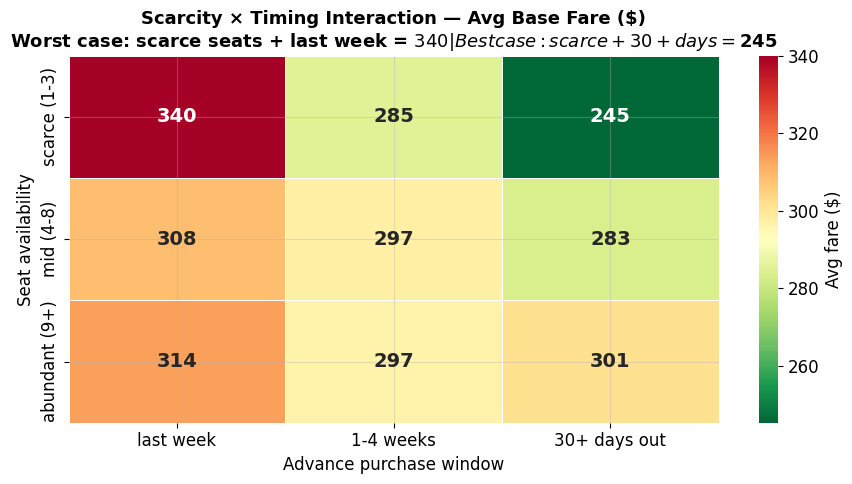

KEY: $340 (scarce+last week) vs $245 (scarce+30+ days) = 39% premium for same product at different times


In [4]:
# ── CELL 4: Chart 2 — Scarcity × Timing heatmap ──────────────
# This is your interaction effect — the key regulatory signal
pivot = df_scarcity_timing.pivot(
    index='SCARCITY_GROUP', columns='TIMING_GROUP', values='AVG_FARE'
)
# Reorder
row_order = ['scarce (1-3)', 'mid (4-8)', 'abundant (9+)']
col_order  = ['last week', '1-4 weeks', '30+ days out']
pivot = pivot.reindex(index=row_order, columns=col_order)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg fare ($)'},
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Scarcity × Timing Interaction — Avg Base Fare ($)\nWorst case: scarce seats + last week = $340 | Best case: scarce + 30+ days = $245')
ax.set_xlabel('Advance purchase window')
ax.set_ylabel('Seat availability')
plt.tight_layout()
plt.savefig('chart2_scarcity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("KEY: $340 (scarce+last week) vs $245 (scarce+30+ days) = 39% premium for same product at different times")

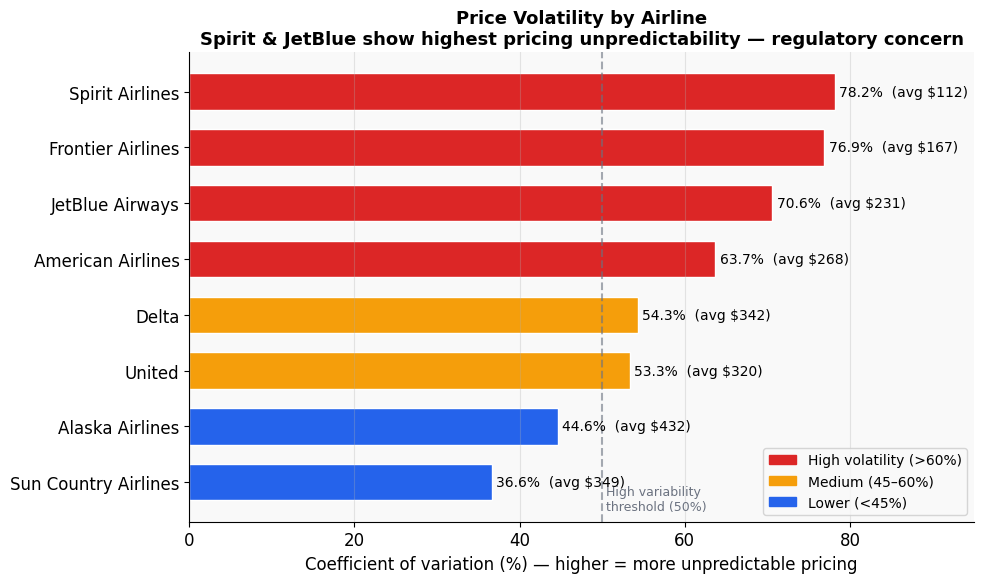

In [5]:
# ── CELL 5: Chart 3 — Airline volatility ─────────────────────
df_vol = df_volatility[df_volatility['NUM_OFFERS'] > 50000].copy()
df_vol = df_vol.sort_values('CV_PCT', ascending=True)

colors_vol = [RED if cv > 60 else ORANGE if cv > 45 else BLUE
              for cv in df_vol['CV_PCT']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_vol['AIRLINE'], df_vol['CV_PCT'],
               color=colors_vol, edgecolor='white', height=0.65)

for bar, val, avg in zip(bars, df_vol['CV_PCT'], df_vol['AVG_FARE']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%  (avg ${avg:.0f})',
            va='center', fontsize=10)

ax.axvline(50, color=GRAY, lw=1.5, ls='--', alpha=0.6)
ax.text(50.5, -0.5, 'High variability\nthreshold (50%)',
        fontsize=9, color=GRAY)
ax.set_xlabel('Coefficient of variation (%) — higher = more unpredictable pricing')
ax.set_title('Price Volatility by Airline\nSpirit & JetBlue show highest pricing unpredictability — regulatory concern')
ax.set_xlim(0, 95)
ax.grid(axis='x', alpha=0.3)
ax.grid(axis='y', alpha=0)

red_p   = mpatches.Patch(color=RED,    label='High volatility (>60%)')
ora_p   = mpatches.Patch(color=ORANGE, label='Medium (45–60%)')
blue_p  = mpatches.Patch(color=BLUE,   label='Lower (<45%)')
ax.legend(handles=[red_p, ora_p, blue_p], loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('chart3_airline_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

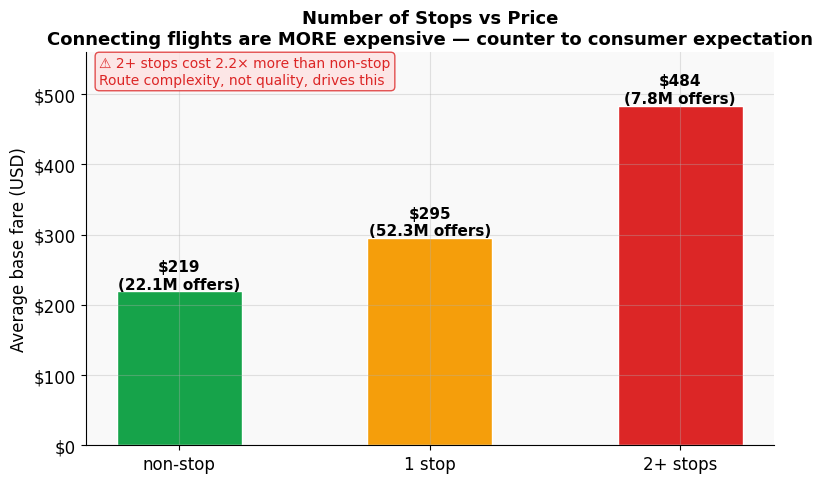

In [6]:
# ── CELL 6: Chart 4 — Stops vs price (counter-intuitive) ──────
df_st = df_stops.dropna().copy()
order = ['non-stop', '1 stop', '2+ stops']
df_st['STOP_TYPE'] = pd.Categorical(df_st['STOP_TYPE'], categories=order, ordered=True)
df_st = df_st.sort_values('STOP_TYPE')

fig, ax = plt.subplots(figsize=(8, 5))
colors_stops = [GREEN, ORANGE, RED]
bars = ax.bar(df_st['STOP_TYPE'], df_st['AVG_FARE'],
              color=colors_stops, width=0.5, edgecolor='white')

for bar, row in zip(bars, df_st.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            f'${row.AVG_FARE:.0f}\n({row.NUM_OFFERS/1e6:.1f}M offers)',
            ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Average base fare (USD)')
ax.set_title('Number of Stops vs Price\nConnecting flights are MORE expensive — counter to consumer expectation')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.set_ylim(0, 560)

ax.text(0.02, 0.92, '⚠ 2+ stops cost 2.2× more than non-stop\nRoute complexity, not quality, drives this',
        transform=ax.transAxes, fontsize=10, color=RED,
        bbox=dict(boxstyle='round', facecolor='#fee2e2', edgecolor=RED, alpha=0.8))
plt.tight_layout()
plt.savefig('chart4_stops_price.png', dpi=150, bbox_inches='tight')
plt.show()

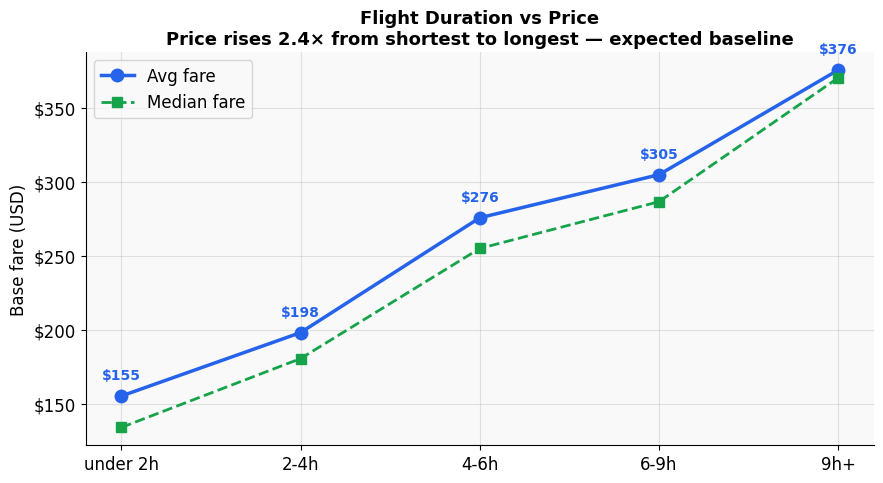

In [7]:
# ── CELL 7: Chart 5 — Duration vs price ───────────────────────
order_d = ['under 2h','2-4h','4-6h','6-9h','9h+']
df_dur = df_duration.copy()
df_dur['DURATION_BUCKET'] = pd.Categorical(
    df_dur['DURATION_BUCKET'], categories=order_d, ordered=True)
df_dur = df_dur.sort_values('DURATION_BUCKET')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_dur['DURATION_BUCKET'], df_dur['AVG_FARE'],
        color=BLUE, lw=2.5, marker='o', markersize=9, label='Avg fare')
ax.plot(df_dur['DURATION_BUCKET'], df_dur['MEDIAN_FARE'],
        color=GREEN, lw=2, marker='s', markersize=7,
        ls='--', label='Median fare')

for i, row in df_dur.iterrows():
    ax.annotate(f'${row.AVG_FARE:.0f}',
                (row['DURATION_BUCKET'], row['AVG_FARE']),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=10, color=BLUE, fontweight='bold')

ax.set_ylabel('Base fare (USD)')
ax.set_title('Flight Duration vs Price\nPrice rises 2.4× from shortest to longest — expected baseline')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('chart5_duration_price.png', dpi=150, bbox_inches='tight')
plt.show()

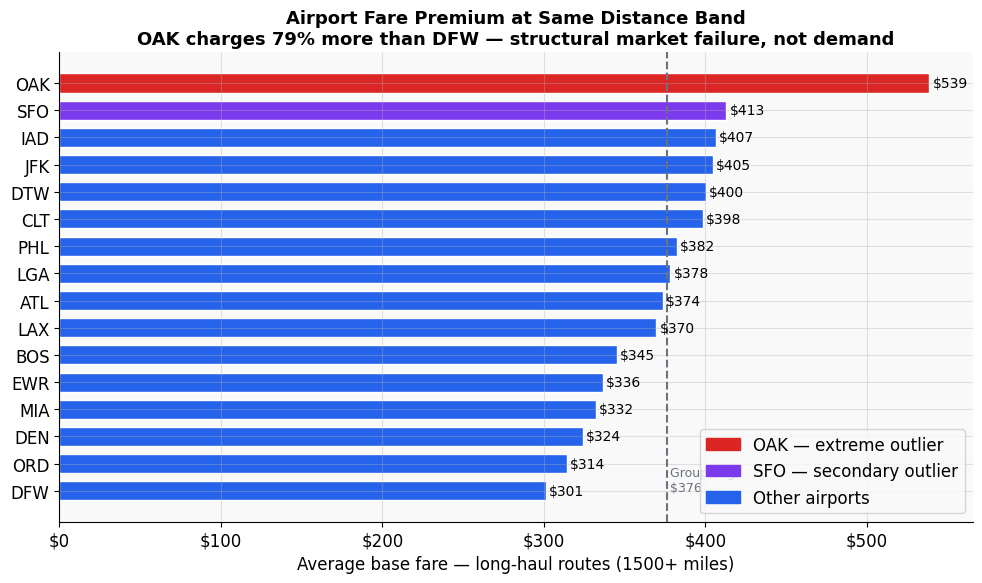

In [8]:
# ── CELL 8: Chart 6 — OAK airport premium ─────────────────────
df_long = df_airport[df_airport['DISTANCE_BAND'] == 'long (1500mi+)'].sort_values('AVG_FARE')

fig, ax = plt.subplots(figsize=(10, 6))
colors_ap = [RED if a == 'OAK' else PURPLE if a == 'SFO' else BLUE
             for a in df_long['STARTINGAIRPORT']]
bars = ax.barh(df_long['STARTINGAIRPORT'], df_long['AVG_FARE'],
               color=colors_ap, edgecolor='white', height=0.7)
for bar, val in zip(bars, df_long['AVG_FARE']):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f'${val:.0f}', va='center', fontsize=10)

avg_line = df_long['AVG_FARE'].mean()
ax.axvline(avg_line, color=GRAY, ls='--', lw=1.5)
ax.text(avg_line+2, 0, f'Group avg\n${avg_line:.0f}', fontsize=9, color=GRAY)

ax.set_xlabel('Average base fare — long-haul routes (1500+ miles)')
ax.set_title('Airport Fare Premium at Same Distance Band\nOAK charges 79% more than DFW — structural market failure, not demand')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

red_p  = mpatches.Patch(color=RED,    label='OAK — extreme outlier')
purp_p = mpatches.Patch(color=PURPLE, label='SFO — secondary outlier')
blue_p = mpatches.Patch(color=BLUE,   label='Other airports')
ax.legend(handles=[red_p, purp_p, blue_p], loc='lower right')
plt.tight_layout()
plt.savefig('chart6_airport_premium.png', dpi=150, bbox_inches='tight')
plt.show()

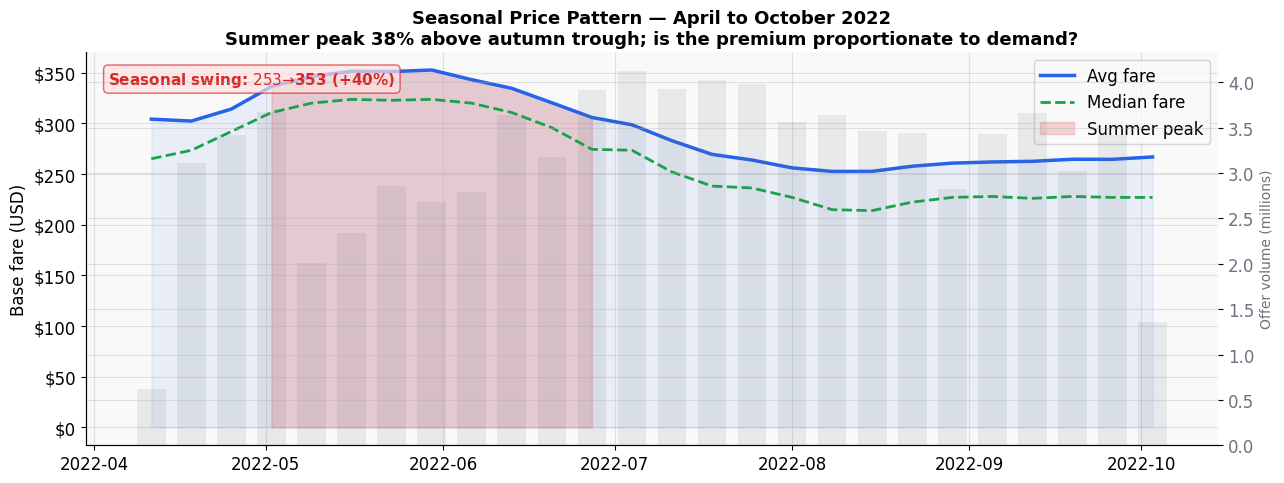

In [9]:
# ── CELL 9: Chart 7 — Seasonal trend ─────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax2.bar(df_seasonal['SEARCH_WEEK'], df_seasonal['NUM_OFFERS']/1e6,
        width=5, alpha=0.12, color=GRAY)
ax2.set_ylabel('Offer volume (millions)', color=GRAY, fontsize=10)
ax2.tick_params(axis='y', labelcolor=GRAY)

ax1.fill_between(df_seasonal['SEARCH_WEEK'], df_seasonal['AVG_FARE'],
                 alpha=0.08, color=BLUE)
ax1.plot(df_seasonal['SEARCH_WEEK'], df_seasonal['AVG_FARE'],
         color=BLUE, lw=2.5, label='Avg fare')
ax1.plot(df_seasonal['SEARCH_WEEK'], df_seasonal['MEDIAN_FARE'],
         color=GREEN, lw=2, ls='--', label='Median fare')

summer = (df_seasonal['SEARCH_WEEK'] >= '2022-05-01') & \
         (df_seasonal['SEARCH_WEEK'] <= '2022-06-30')
ax1.fill_between(df_seasonal['SEARCH_WEEK'], df_seasonal['AVG_FARE'],
                 where=summer, alpha=0.18, color=RED, label='Summer peak')

peak = df_seasonal['AVG_FARE'].max()
trough = df_seasonal['AVG_FARE'].min()
ax1.text(0.02, 0.92,
         f'Seasonal swing: ${trough:.0f} → ${peak:.0f} (+{(peak-trough)/trough*100:.0f}%)',
         transform=ax1.transAxes, color=RED, fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='#fee2e2', edgecolor=RED, alpha=0.7))

ax1.set_ylabel('Base fare (USD)')
ax1.set_title('Seasonal Price Pattern — April to October 2022\nSummer peak 38% above autumn trough; is the premium proportionate to demand?')
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, loc='upper right')
plt.tight_layout()
plt.savefig('chart7_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

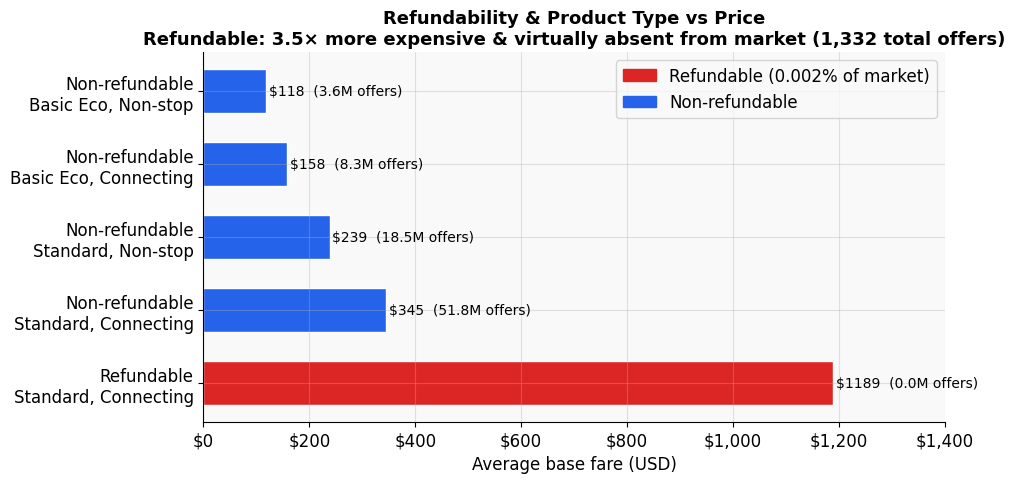

In [10]:
# ── CELL 10: Chart 8 — Refundability market failure ───────────
df_ref = df_refundable[df_refundable['NUM_OFFERS'] > 1000].copy()
df_ref['label'] = df_ref.apply(lambda r:
    ('Refundable' if r['ISREFUNDABLE'] else 'Non-refundable') + '\n' +
    ('Basic Eco' if r['ISBASICECONOMY'] else 'Standard') + ', ' +
    ('Non-stop' if r['ISNONSTOP'] else 'Connecting'), axis=1)

df_ref_sorted = df_ref.sort_values('AVG_FARE', ascending=False)
bar_colors = [RED if r else BLUE for r in df_ref_sorted['ISREFUNDABLE']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_ref_sorted['label'], df_ref_sorted['AVG_FARE'],
               color=bar_colors, edgecolor='white', height=0.6)
for bar, row in zip(bars, df_ref_sorted.itertuples()):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'${row.AVG_FARE:.0f}  ({row.NUM_OFFERS/1e6:.1f}M offers)',
            va='center', fontsize=10)

ax.set_xlabel('Average base fare (USD)')
ax.set_title('Refundability & Product Type vs Price\nRefundable: 3.5× more expensive & virtually absent from market (1,332 total offers)')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

red_p  = mpatches.Patch(color=RED,  label='Refundable (0.002% of market)')
blue_p = mpatches.Patch(color=BLUE, label='Non-refundable')
ax.legend(handles=[red_p, blue_p])
ax.set_xlim(0, 1400)
plt.tight_layout()
plt.savefig('chart8_refundability.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── CELL 11: Summary findings for presentation ────────────────
summary = [
    ('Last-minute cliff',        '+24%',  'Day 1 vs day 45', '🔴 HIGH'),
    ('Scarcity × timing',        '+39%',  'Scarce+last-week vs scarce+30d', '🔴 HIGH'),
    ('Spirit price volatility',  '78% CV','vs 16% for stable carriers', '🔴 HIGH'),
    ('OAK airport premium',      '+79%',  'vs DFW at same distance', '🔴 HIGH'),
    ('Fee loading ($70/$108)',   '3–4×',  'multiplier on 4M+ offers', '🔴 HIGH'),
    ('Refundability absent',     '0.002%','market effectively non-refundable', '🔴 HIGH'),
    ('Stops more expensive',     '+121%', '2-stop vs non-stop', '🟡 MEDIUM'),
    ('Summer peak',              '+38%',  'May-June vs Aug-Sep', '🟡 MEDIUM'),
    ('Monopoly (naive)',         'REJECTED','confounded by distance', '⚪ NEEDS RERUN'),
    ('Same-day search',          'N/A',   'No same-day offers in dataset', '⚪ DROP'),
    ('Cabin class',              '99.9%', 'coach — not useful variable', '⚪ DROP'),
    ('Refundable variable',      'DROP',  '0.002% — no analytical value', '⚪ DROP'),
]

df_summary = pd.DataFrame(summary, columns=['Finding','Magnitude','Context','Signal'])
print(df_summary.to_string(index=False))
df_summary.to_csv('eda_master_findings.csv', index=False)
print("\nAll charts saved. EDA phase complete.")

                Finding Magnitude                           Context        Signal
      Last-minute cliff      +24%                   Day 1 vs day 45        🔴 HIGH
      Scarcity × timing      +39%    Scarce+last-week vs scarce+30d        🔴 HIGH
Spirit price volatility    78% CV        vs 16% for stable carriers        🔴 HIGH
    OAK airport premium      +79%           vs DFW at same distance        🔴 HIGH
 Fee loading ($70/$108)      3–4×          multiplier on 4M+ offers        🔴 HIGH
   Refundability absent    0.002% market effectively non-refundable        🔴 HIGH
   Stops more expensive     +121%                2-stop vs non-stop      🟡 MEDIUM
            Summer peak      +38%               May-June vs Aug-Sep      🟡 MEDIUM
       Monopoly (naive)  REJECTED            confounded by distance ⚪ NEEDS RERUN
        Same-day search       N/A     No same-day offers in dataset        ⚪ DROP
            Cabin class     99.9%       coach — not useful variable        ⚪ DROP
    Refundable v

# ML MODEL

In [12]:
# ── CELL 2: Load the ML_FEATURES.csv ──────────────────────────
uploaded = files.upload()   # upload ML_FEATURES.csv when prompted
df = pd.read_csv(list(uploaded.keys())[0])
print(f"Loaded: {len(df):,} rows, {df.shape[1]} columns")
print(df.dtypes)
df.head()

Saving ML_Feature_Table.csv to ML_Feature_Table.csv
Loaded: 819,923 rows, 20 columns
LEGID                   object
DAYS_ADVANCE             int64
BASEFARE               float64
TOTALFARE              float64
FEE_MULTIPLIER         float64
TOTALTRAVELDISTANCE    float64
SEATSREMAINING           int64
IS_SCARCE                int64
IS_NONSTOP               int64
IS_BASIC_ECONOMY         int64
NUM_STOPS                int64
IS_OAK_ORIGIN            int64
IS_BAY_AREA              int64
AIRLINE                 object
STARTINGAIRPORT         object
DESTINATIONAIRPORT      object
ROUTE                   object
FLIGHT_DOW               int64
FLIGHT_MONTH             int64
SCARCE_LASTMINUTE        int64
dtype: object


,LEGID,DAYS_ADVANCE,BASEFARE,TOTALFARE,FEE_MULTIPLIER,TOTALTRAVELDISTANCE,SEATSREMAINING,IS_SCARCE,IS_NONSTOP,IS_BASIC_ECONOMY,NUM_STOPS,IS_OAK_ORIGIN,IS_BAY_AREA,AIRLINE,STARTINGAIRPORT,DESTINATIONAIRPORT,ROUTE,FLIGHT_DOW,FLIGHT_MONTH,SCARCE_LASTMINUTE
0,2d509c9d13f11d71c0625771a2737710,5,512.01,574.01,1.1211,1604.0,4,0,0,0,1,0,1,Frontier Airlines,SFO,DFW,SFO_DFW,4,5,0
1,fcde379d3cbee20c99e842463c1814b9,5,473.49,532.60,1.1248,2569.0,7,0,0,0,1,0,1,United,SFO,JFK,SFO_JFK,4,5,0
2,5c75f391ab7cc3a978f813a6d8407cb6,5,543.25,607.59,1.1184,2599.0,2,1,0,0,1,0,1,United,SFO,MIA,SFO_MIA,4,5,1
3,c9ab9c118bca6545a942804207fc1953,6,263.00,370.58,1.4090,NaN,0,1,0,0,1,0,0,Spirit Airlines,DFW,CLT,DFW_CLT,5,5,1
4,a8d1096d9ced2017c0808c5b11c78a52,6,178.00,285.58,1.6044,NaN,0,1,0,0,1,0,0,Spirit Airlines,DFW,EWR,DFW_EWR,5,5,1


In [13]:
# ── CELL 3: Clean & prepare features ──────────────────────────
# These are the numeric features we feed into ML
# We drop text columns (airline, route etc) for clustering
# but keep them to label the results afterwards

FEATURES = [
    'DAYS_ADVANCE',
    'BASEFARE',
    'FEE_MULTIPLIER',
    'SEATSREMAINING',
    'IS_SCARCE',
    'IS_NONSTOP',
    'IS_BASIC_ECONOMY',
    'NUM_STOPS',
    'IS_OAK_ORIGIN',
    'IS_BAY_AREA',
    'FLIGHT_DOW',
    'FLIGHT_MONTH',
    'SCARCE_LASTMINUTE',
]

# Drop rows where any feature is null
df_clean = df[FEATURES + ['AIRLINE', 'ROUTE', 'STARTINGAIRPORT',
                           'DESTINATIONAIRPORT']].dropna()
df_clean = df_clean.reset_index(drop=True)

# Also drop fee_multiplier outliers (values above 5 are likely data errors)
df_clean = df_clean[df_clean['FEE_MULTIPLIER'] < 5]

print(f"Clean rows: {len(df_clean):,}")
print(f"\nFeature summary:")
print(df_clean[FEATURES].describe().round(2))

Clean rows: 812,110

Feature summary:
       DAYS_ADVANCE   BASEFARE  FEE_MULTIPLIER  SEATSREMAINING  IS_SCARCE  \
count     812110.00  812110.00       812110.00       812110.00  812110.00   
mean          26.83     294.76            1.22            6.03       0.22   
std           16.32     177.01            0.27            2.84       0.42   
min            1.00       6.00            1.05            0.00       0.00   
25%           13.00     161.86            1.13            4.00       0.00   
50%           26.00     263.25            1.16            7.00       0.00   
75%           40.00     399.07            1.21            9.00       0.00   
max           60.00    1990.69            4.98           10.00       1.00   

       IS_NONSTOP  IS_BASIC_ECONOMY  NUM_STOPS  IS_OAK_ORIGIN  IS_BAY_AREA  \
count   812110.00         812110.00  812110.00      812110.00    812110.00   
mean         0.27              0.14       0.83           0.05         0.12   
std          0.44              0.3

In [14]:
# ── CELL 4: Scale features ─────────────────────────────────────
# StandardScaler makes all features comparable in magnitude
# Without scaling, baseFare (0-2000) would dominate over binary flags (0/1)
X = df_clean[FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled matrix shape: {X_scaled.shape}")
print("Mean after scaling (should be ~0):", X_scaled.mean(axis=0).round(3))

Scaled matrix shape: (812110, 13)
Mean after scaling (should be ~0): [-0. -0. -0.  0. -0.  0. -0.  0. -0.  0.  0. -0.  0.]


# CHARTS

Variance explained by PC1: 20.5%
Variance explained by PC2: 17.0%
Total: 37.5%


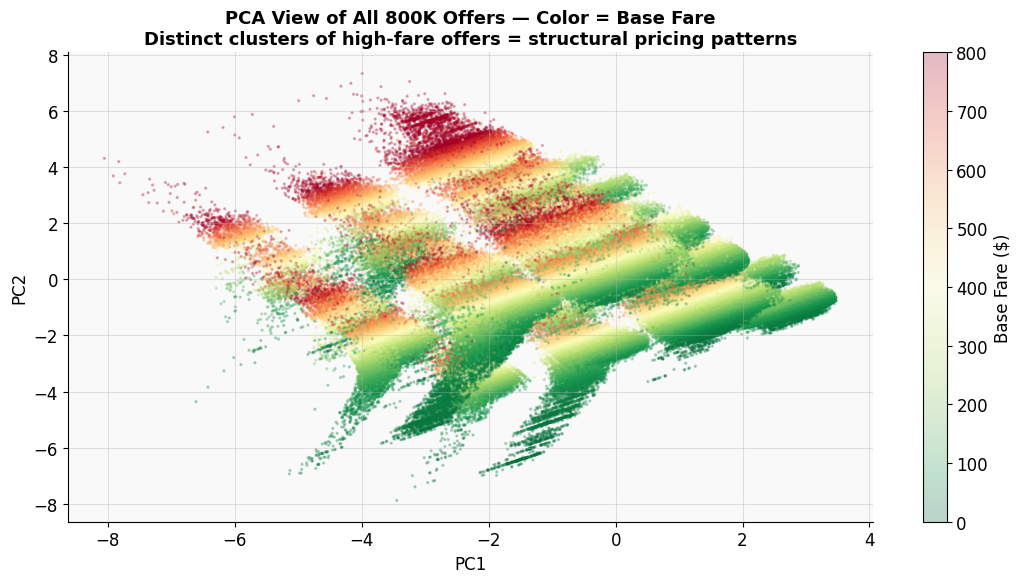

In [17]:
# ── CELL 5: PCA — compress to 2D to visualize ─────────────────
# PCA keeps the most important variation while letting us plot it
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Color points by baseFare to see structure
fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=df_clean['BASEFARE'], cmap='RdYlGn_r',
                alpha=0.25, s=2, vmin=0, vmax=800)
plt.colorbar(sc, ax=ax, label='Base Fare ($)')
ax.set_title('PCA View of All 800K Offers — Color = Base Fare\nDistinct clusters of high-fare offers = structural pricing patterns')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.savefig('ml_pca_overview.png', dpi=150, bbox_inches='tight')
plt.show()
# What to look for: dark red clumps separated from the blue mass = anomaly zones

k=3: inertia=7,602,101, silhouette=0.2056
k=4: inertia=6,555,938, silhouette=0.2317
k=5: inertia=5,830,970, silhouette=0.2566
k=6: inertia=5,132,881, silhouette=0.2780
k=7: inertia=4,843,504, silhouette=0.2203
k=8: inertia=4,334,927, silhouette=0.2346
k=9: inertia=4,050,116, silhouette=0.2388
k=10: inertia=3,841,704, silhouette=0.2543


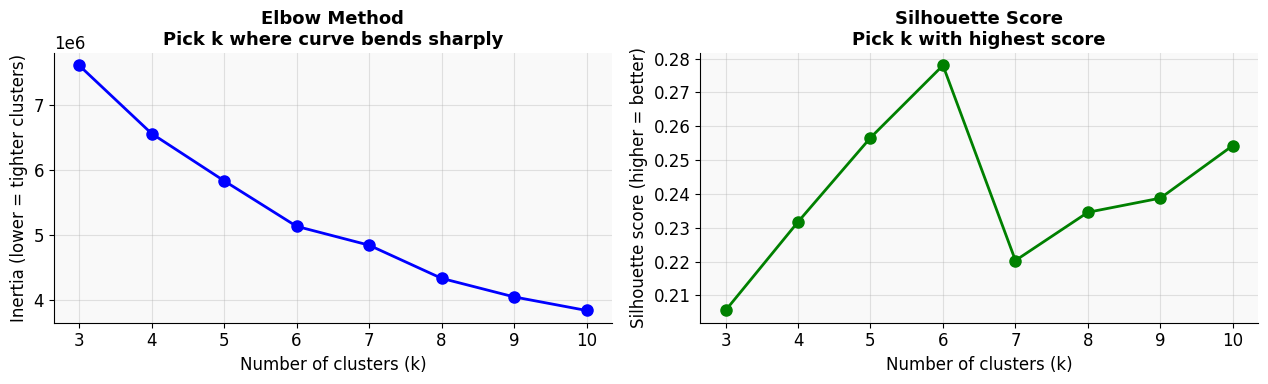


Look at both charts. Pick k where elbow bends AND silhouette peaks.
Usually this will be k=5 or k=6 for this dataset.


In [18]:
# ── CELL 6: Elbow method — find the right number of clusters ───
# This tells us how many natural groups exist in the data
inertias = []
silhouettes = []
K_range = range(3, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    silhouettes.append(sil)
    print(f"k={k}: inertia={km.inertia_:,.0f}, silhouette={sil:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(K_range, inertias, 'bo-', lw=2, markersize=8)
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia (lower = tighter clusters)')
ax1.set_title('Elbow Method\nPick k where curve bends sharply')

ax2.plot(K_range, silhouettes, 'go-', lw=2, markersize=8)
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette score (higher = better)')
ax2.set_title('Silhouette Score\nPick k with highest score')

plt.tight_layout()
plt.savefig('ml_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nLook at both charts. Pick k where elbow bends AND silhouette peaks.")
print("Usually this will be k=5 or k=6 for this dataset.")

In [19]:
# ── CELL 7: Fit final K-Means ──────────────────────────────────
# SET THIS based on what you saw in Cell 6
K_FINAL = 6   # adjust after looking at elbow + silhouette plots

km = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10, max_iter=300)
df_clean['cluster'] = km.fit_predict(X_scaled)

print(f"K-Means fitted with k={K_FINAL}")
print("\nCluster sizes:")
print(df_clean['cluster'].value_counts().sort_index())

K-Means fitted with k=6

Cluster sizes:
cluster
0    115996
1     37305
2    336944
3     37248
4    150984
5    133633
Name: count, dtype: int64


In [20]:
# ── CELL 8: Profile each cluster ──────────────────────────────
# This is where you understand WHAT each cluster represents
profile = df_clean.groupby('cluster').agg(
    n_offers        = ('BASEFARE', 'count'),
    avg_fare        = ('BASEFARE', 'mean'),
    median_fare     = ('BASEFARE', 'median'),
    avg_days_advance= ('DAYS_ADVANCE', 'mean'),
    avg_seats       = ('SEATSREMAINING', 'mean'),
    pct_scarce      = ('IS_SCARCE', 'mean'),
    pct_nonstop     = ('IS_NONSTOP', 'mean'),
    pct_basic_eco   = ('IS_BASIC_ECONOMY', 'mean'),
    avg_stops       = ('NUM_STOPS', 'mean'),
    pct_oak         = ('IS_OAK_ORIGIN', 'mean'),
    avg_fee_mult    = ('FEE_MULTIPLIER', 'mean'),
    pct_scarce_lm   = ('SCARCE_LASTMINUTE', 'mean'),
).round(3)

# Sort by avg_fare so highest-priced cluster is at top
profile = profile.sort_values('avg_fare', ascending=False)
print(profile.to_string())
profile.to_csv('cluster_profiles.csv')

# What to look for per cluster:
# High avg_fare + low days_advance + high pct_scarce = last-minute scarcity cluster
# High avg_fee_mult + low avg_fare                   = hidden fee cluster
# High pct_oak = OAK structural premium cluster
# Low avg_fare + high pct_basic_eco                  = budget cluster
# Mid fare + high pct_nonstop                        = business traveller cluster

         n_offers  avg_fare  median_fare  avg_days_advance  avg_seats  pct_scarce  pct_nonstop  pct_basic_eco  avg_stops  pct_oak  avg_fee_mult  pct_scarce_lm
cluster                                                                                                                                                       
1           37305   470.863       475.35            27.694      5.525       0.297        0.012          0.043      1.535    1.000         1.214          0.055
2          336944   353.998       338.60            27.708      7.101       0.000        0.000          0.000      1.107    0.000         1.165          0.000
3           37248   328.289       303.26             3.860      1.548       1.000        0.192          0.001      0.917    0.008         1.243          1.000
5          133633   276.716       251.16            28.260      1.443       1.000        0.177          0.000      0.934    0.000         1.395          0.000
4          150984   241.872       211.16      

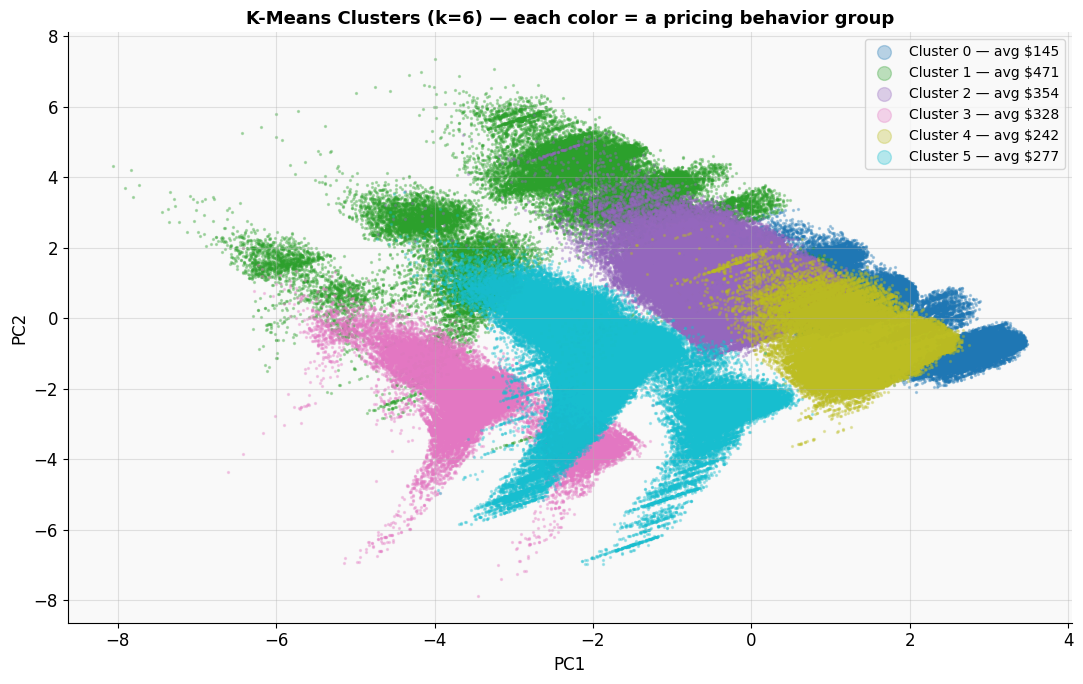

In [21]:
# ── CELL 9: Visualize clusters in PCA space ───────────────────
import matplotlib.cm as cm
colors = cm.tab10(np.linspace(0, 1, K_FINAL))

fig, ax = plt.subplots(figsize=(11, 7))
for c in range(K_FINAL):
    mask = df_clean['cluster'] == c
    avg_f = df_clean.loc[mask, 'BASEFARE'].mean()
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colors[c]], alpha=0.3, s=2,
               label=f'Cluster {c} — avg ${avg_f:.0f}')

ax.set_title(f'K-Means Clusters (k={K_FINAL}) — each color = a pricing behavior group')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(markerscale=7, fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig('ml_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

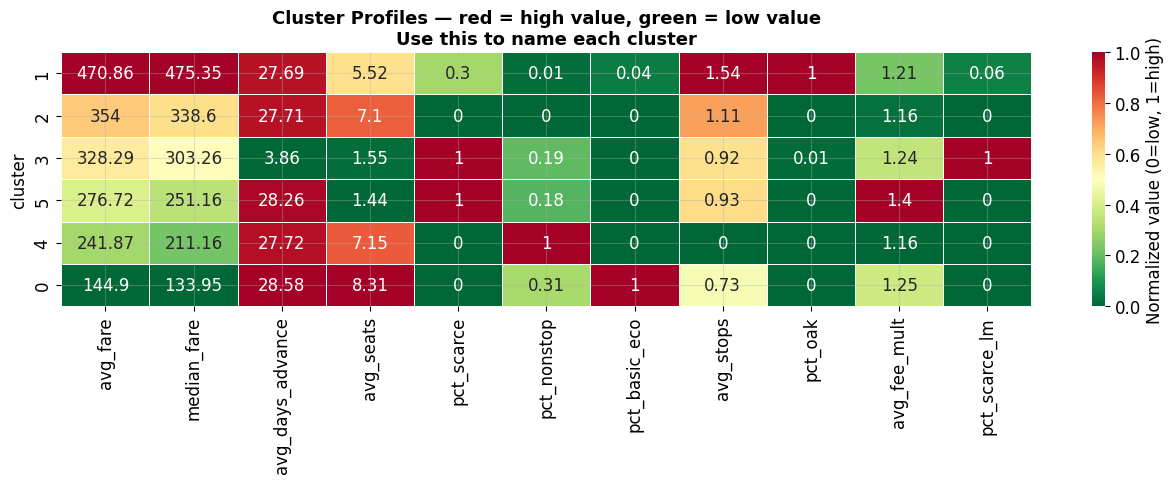

In [22]:
# ── CELL 10: Cluster heatmap — easier to read than a table ────
fig, ax = plt.subplots(figsize=(13, 5))

# Normalize each column to 0-1 so colors are comparable
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
profile_norm = profile_norm.drop(columns=['n_offers'])

sns.heatmap(profile_norm, annot=profile.drop(columns=['n_offers']).round(2),
            fmt='g', cmap='RdYlGn_r', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Normalized value (0=low, 1=high)'})
ax.set_title('Cluster Profiles — red = high value, green = low value\nUse this to name each cluster')
plt.tight_layout()
plt.savefig('ml_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── CELL 11: Isolation Forest — anomaly detection ─────────────
# This finds the specific offers that are hardest to explain
# contamination=0.03 means we expect ~3% of offers to be anomalous
print("Fitting Isolation Forest... (may take 1-2 minutes)")

iso = IsolationForest(
    contamination=0.03,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
df_clean['anomaly_flag']  = iso.fit_predict(X_scaled)   # -1=anomaly, 1=normal
df_clean['anomaly_score'] = iso.decision_function(X_scaled)  # lower = more anomalous

n_anomalies = (df_clean['anomaly_flag'] == -1).sum()
print(f"\nAnomalies detected: {n_anomalies:,} ({n_anomalies/len(df_clean)*100:.1f}%)")

Fitting Isolation Forest... (may take 1-2 minutes)

Anomalies detected: 24,364 (3.0%)


In [24]:
# ── CELL 12: Compare anomalies vs normal offers ────────────────
comparison = df_clean.groupby('anomaly_flag').agg(
    count           = ('BASEFARE', 'count'),
    avg_fare        = ('BASEFARE', 'mean'),
    avg_fee_mult    = ('FEE_MULTIPLIER', 'mean'),
    avg_days_advance= ('DAYS_ADVANCE', 'mean'),
    avg_seats       = ('SEATSREMAINING', 'mean'),
    pct_scarce      = ('IS_SCARCE', 'mean'),
    pct_oak         = ('IS_OAK_ORIGIN', 'mean'),
    pct_scarce_lm   = ('SCARCE_LASTMINUTE', 'mean'),
).round(3)
comparison.index = ['Anomaly (-1)', 'Normal (1)']
print(comparison.to_string())
comparison.to_csv('anomaly_vs_normal.csv')
# KEY: anomalies should show higher fare, higher fee_mult, higher pct_scarce_lm

               count  avg_fare  avg_fee_mult  avg_days_advance  avg_seats  pct_scarce  pct_oak  pct_scarce_lm
Anomaly (-1)   24364   394.200         1.500            21.617      2.769       0.731    0.600          0.313
Normal (1)    787746   291.683         1.211            26.992      6.126       0.208    0.029          0.040


/tmp/ipykernel_11594/207408808.py:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_11594/207408808.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('ml_anomalies_pca.png', dpi=150, bbox_inches='tight')


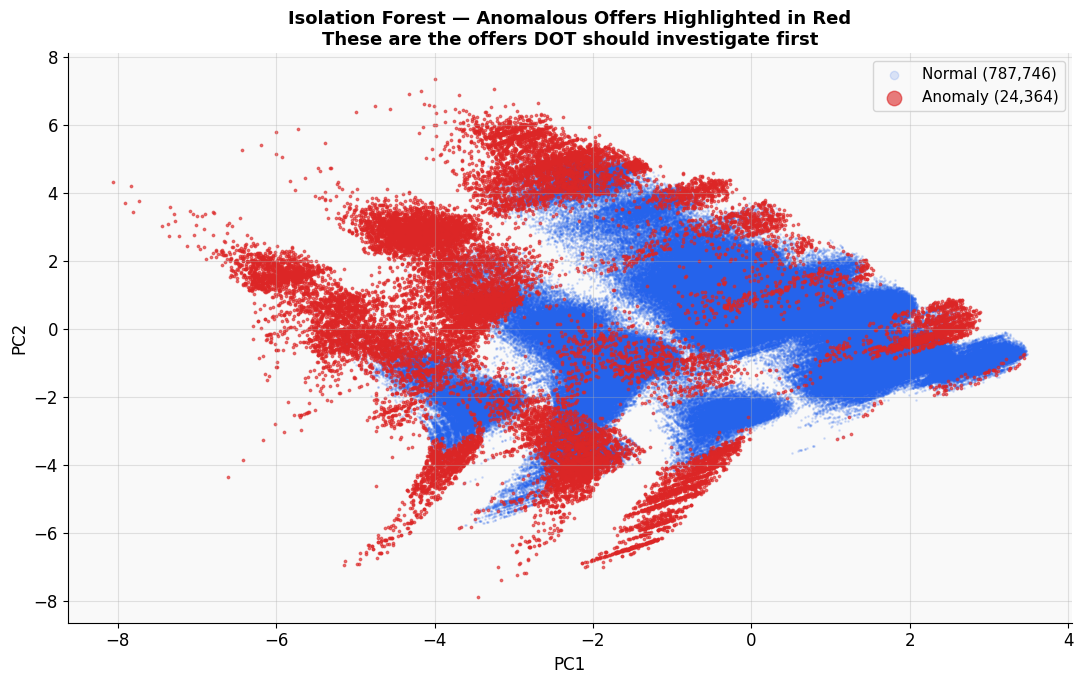

In [25]:
# ── CELL 13: Visualize anomalies in PCA space ─────────────────
normal_mask  = df_clean['anomaly_flag'] == 1
anomaly_mask = df_clean['anomaly_flag'] == -1

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(X_pca[normal_mask, 0],  X_pca[normal_mask, 1],
           c=BLUE, alpha=0.15, s=1, label=f'Normal ({normal_mask.sum():,})')
ax.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1],
           c=RED,  alpha=0.6,  s=3, label=f'Anomaly ({anomaly_mask.sum():,})')
ax.set_title('Isolation Forest — Anomalous Offers Highlighted in Red\nThese are the offers DOT should investigate first')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(markerscale=6, fontsize=11)
plt.tight_layout()
plt.savefig('ml_anomalies_pca.png', dpi=150, bbox_inches='tight')
plt.show()

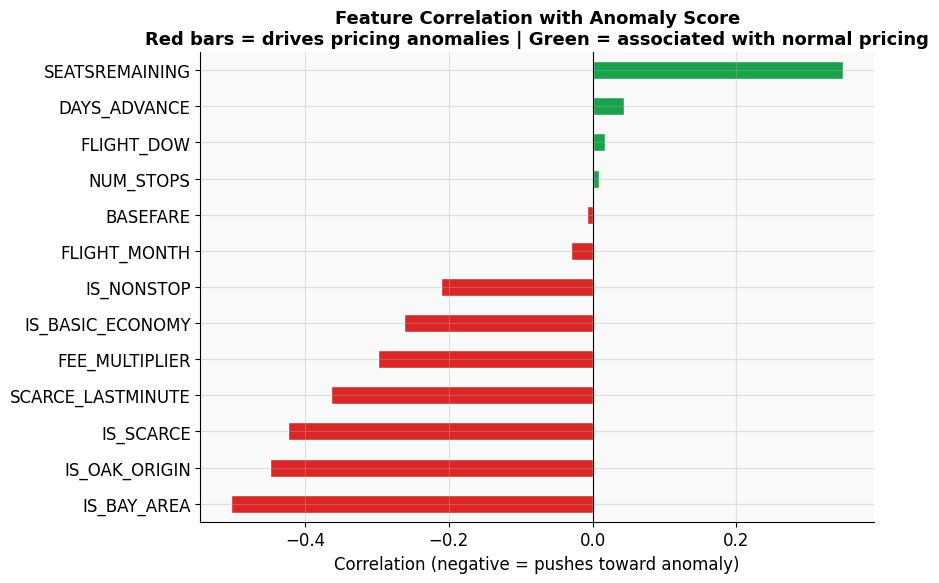


Top anomaly drivers (most negative):
IS_BAY_AREA         -0.503091
IS_OAK_ORIGIN       -0.449519
IS_SCARCE           -0.423812
SCARCE_LASTMINUTE   -0.364360
FEE_MULTIPLIER      -0.298078
dtype: float64


In [26]:
# ── CELL 14: Which features drive anomalies? ──────────────────
# Correlation between each feature and the anomaly score
# Negative correlation = that feature pushes toward being an anomaly
corr = pd.Series(
    np.corrcoef(X_scaled.T,
                df_clean['anomaly_score'].values)[:-1, -1],
    index=FEATURES
).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = [RED if v < 0 else GREEN for v in corr.values]
corr.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Correlation with Anomaly Score\nRed bars = drives pricing anomalies | Green = associated with normal pricing')
ax.set_xlabel('Correlation (negative = pushes toward anomaly)')
plt.tight_layout()
plt.savefig('ml_anomaly_drivers.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTop anomaly drivers (most negative):")
print(corr.head(5))

In [27]:
# ── CELL 15: Top anomalous routes & airlines ───────────────────
anomalies_only = df_clean[df_clean['anomaly_flag'] == -1]

# By route
top_routes = (anomalies_only
    .groupby('ROUTE')
    .agg(
        anomaly_count   = ('BASEFARE', 'count'),
        avg_fare        = ('BASEFARE', 'mean'),
        avg_fee_mult    = ('FEE_MULTIPLIER', 'mean'),
        avg_days_advance= ('DAYS_ADVANCE', 'mean'),
    )
    .round(2)
    .sort_values('anomaly_count', ascending=False)
    .head(20))

print("TOP 20 ROUTES BY ANOMALY COUNT:")
print(top_routes.to_string())
top_routes.to_csv('top_anomaly_routes.csv')

# By airline
top_airlines = (anomalies_only
    .groupby('AIRLINE')
    .agg(
        anomaly_count = ('BASEFARE', 'count'),
        avg_fare      = ('BASEFARE', 'mean'),
        avg_fee_mult  = ('FEE_MULTIPLIER', 'mean'),
    )
    .round(2)
    .sort_values('anomaly_count', ascending=False))

print("\nANOMALIES BY AIRLINE:")
print(top_airlines.to_string())
top_airlines.to_csv('anomaly_by_airline.csv')

TOP 20 ROUTES BY ANOMALY COUNT:
         anomaly_count  avg_fare  avg_fee_mult  avg_days_advance
ROUTE                                                           
OAK_DFW           1919    260.76          1.66             24.76
OAK_LGA           1534    629.90          1.13             22.61
OAK_ATL           1377    458.85          1.30             26.72
OAK_ORD           1210    387.58          1.45             25.06
OAK_PHL           1121    550.62          1.25             23.45
OAK_DTW           1111    496.07          1.26             26.24
SFO_LAX           1076     90.24          1.34             26.84
OAK_BOS            967    659.12          1.14             24.55
OAK_CLT            918    643.19          1.18             24.72
OAK_LAX            869    227.45          1.68             25.53
OAK_MIA            852    614.42          1.21             24.96
OAK_DEN            727    294.58          1.54             24.48
OAK_EWR            636    457.93          1.38            

In [28]:
# ── CELL 16: Save everything ───────────────────────────────────
# Download all output files
for fname in ['cluster_profiles.csv', 'anomaly_vs_normal.csv',
              'top_anomaly_routes.csv', 'anomaly_by_airline.csv']:
    files.download(fname)

for img in ['ml_pca_overview.png', 'ml_elbow.png', 'ml_clusters_pca.png',
            'ml_cluster_heatmap.png', 'ml_anomalies_pca.png',
            'ml_anomaly_drivers.png']:
    files.download(img)

print("All files downloaded. ML phase complete.")
print("\nNext step: share your cluster_profiles.csv and anomaly results here")
print("and I will help you interpret which clusters = which pricing behavior.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded. ML phase complete.

Next step: share your cluster_profiles.csv and anomaly results here
and I will help you interpret which clusters = which pricing behavior.


# CORRELATION ANALYSIS

In [29]:
# ── CELL 17: Correlation Matrix ───────────────────────────────
# Calculate the correlation matrix for the features
correlation_matrix = df_clean[FEATURES].corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix.round(2))

Correlation Matrix:


,DAYS_ADVANCE,BASEFARE,FEE_MULTIPLIER,SEATSREMAINING,IS_SCARCE,IS_NONSTOP,IS_BASIC_ECONOMY,NUM_STOPS,IS_OAK_ORIGIN,IS_BAY_AREA,FLIGHT_DOW,FLIGHT_MONTH,SCARCE_LASTMINUTE
DAYS_ADVANCE,1.00,-0.06,0.04,0.15,-0.13,0.02,0.04,-0.01,0.01,0.01,-0.01,0.23,-0.32
BASEFARE,-0.06,1.00,-0.36,0.03,-0.00,-0.26,-0.35,0.37,0.22,0.25,-0.04,-0.17,0.06
FEE_MULTIPLIER,0.04,-0.36,1.00,-0.33,0.29,-0.07,0.04,0.02,-0.00,-0.05,0.02,0.06,0.02
SEATSREMAINING,0.15,0.03,-0.33,1.00,-0.87,0.12,0.33,-0.11,-0.04,-0.01,0.02,0.15,-0.36
IS_SCARCE,-0.13,-0.00,0.29,-0.87,1.00,-0.12,-0.22,0.12,0.04,0.02,-0.01,-0.14,0.42
IS_NONSTOP,0.02,-0.26,-0.07,0.12,-0.12,1.00,0.03,-0.86,-0.13,-0.10,-0.02,-0.04,-0.04
IS_BASIC_ECONOMY,0.04,-0.35,0.04,0.33,-0.22,0.03,1.00,-0.06,-0.06,-0.05,0.03,0.25,-0.09
NUM_STOPS,-0.01,0.37,0.02,-0.11,0.12,-0.86,-0.06,1.00,0.26,0.18,0.01,0.05,0.05
IS_OAK_ORIGIN,0.01,0.22,-0.00,-0.04,0.04,-0.13,-0.06,0.26,1.00,0.61,-0.00,0.03,0.02
IS_BAY_AREA,0.01,0.25,-0.05,-0.01,0.02,-0.10,-0.05,0.18,0.61,1.00,-0.00,0.02,0.01


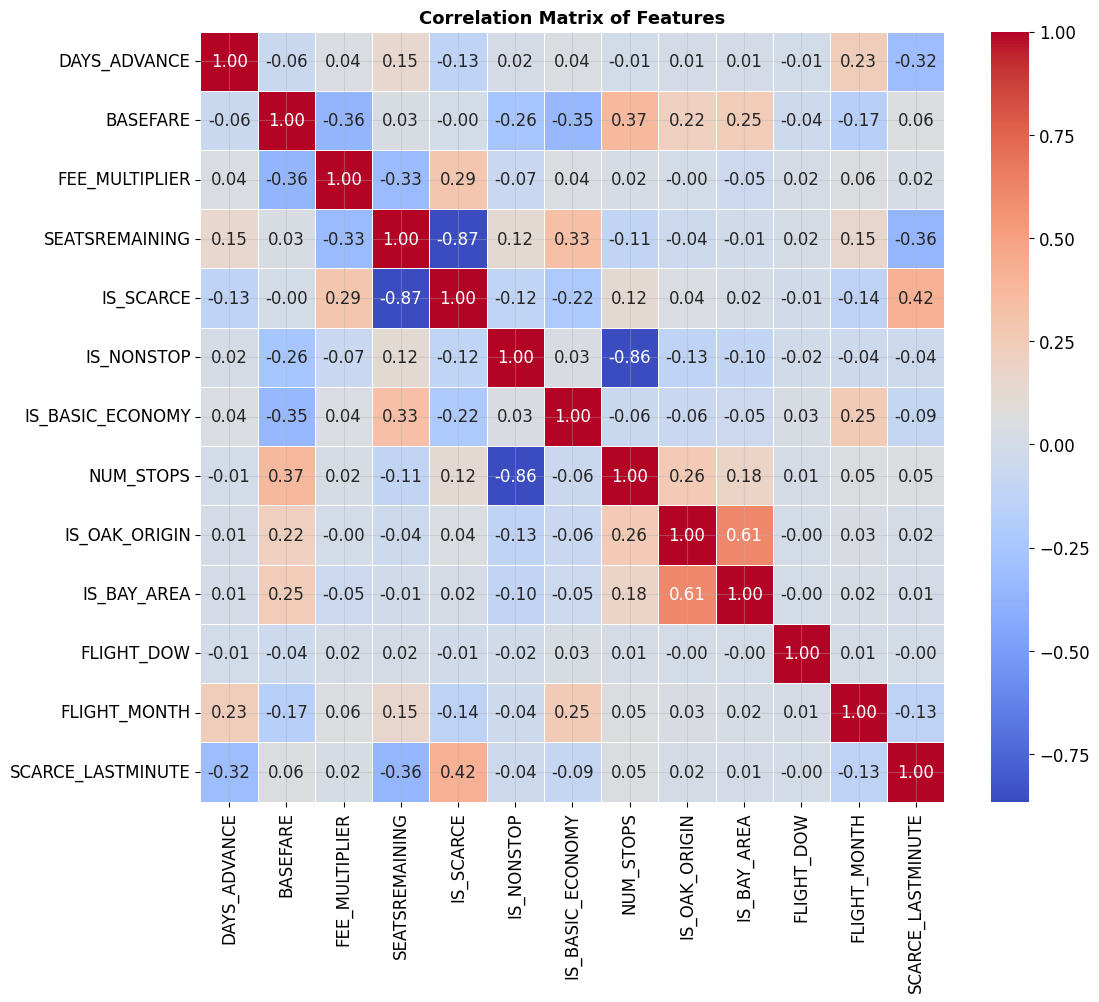

<Figure size 640x480 with 0 Axes>

In [30]:
# ── CELL 18: Correlation Heatmap ──────────────────────────────
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')